In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import re

# Determine the subthreshold electric field strength

Using a simple neuron with no synapses.

In [2]:
def plot_subthreshold_amplitude(data, phi, psi, carrier):
    dt = data[
        (data.Phi == phi) &
        (data.Psi == psi) &
        (data.Carrier == carrier) &
        (data.Offset > 0.5)
    ]
    
    dt2 = data[
        (data.Phi == phi) &
        (data.Psi == psi) &
        (data.Carrier == carrier) &
        (data.Offset > 0.5) &
        (data.Offset <= 20)
    ]
    
    fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 4))
    axs = axs.flatten()
    
    axs[0].plot(dt.Offset, dt.Amplitude, linewidth = 0.5, color = "black")
    axs[0].scatter(dt.Offset, dt.Amplitude, s = 5, color = "black")
    axs[0].set_xlabel("Offset frequency, Hz")
    axs[0].set_ylabel("Electric field amplitude, V/m")
    axs[0].grid()
    
    axs[1].plot(dt2.Offset, dt2.Amplitude, linewidth = 0.5, color = "black")
    axs[1].scatter(dt2.Offset, dt2.Amplitude, s = 5, color = "black")
    axs[1].set_xlabel("Offset frequency, Hz")
    axs[1].set_ylabel("Electric field amplitude, V/m")
    axs[1].grid()
    
    fig.suptitle(
        "Subthreshold EF amplitude\n" + fr"($\phi$ = {phi}, $\psi$ = {psi}, $f_{{\text{{carrier}}}}$ = {carrier}" +
        (", phase = 10)" if carrier != 0 else ")")
    )

In [3]:
subthreshold = []

for file in glob.glob("output/temporal-interference/ef/*_*_*.csv"):
    pattern = re.compile(r"([^/]+)_([^/]+)_([^/]+)\.csv$")
    phi, psi, carrier = pattern.search(file).groups()
    
    data = pd.read_csv(file)
    data["Phi"] = int(phi)
    data["Psi"] = int(psi)
    data["Carrier"] = int(carrier)

    subthreshold.append(data)

subthreshold = pd.concat(subthreshold, ignore_index = True)

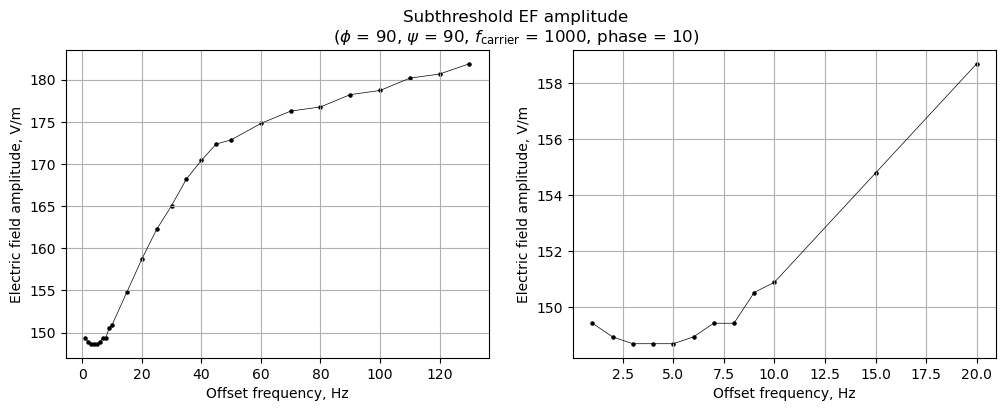

In [4]:
plot_subthreshold_amplitude(subthreshold, phi = 90, psi = 90, carrier = 1000)

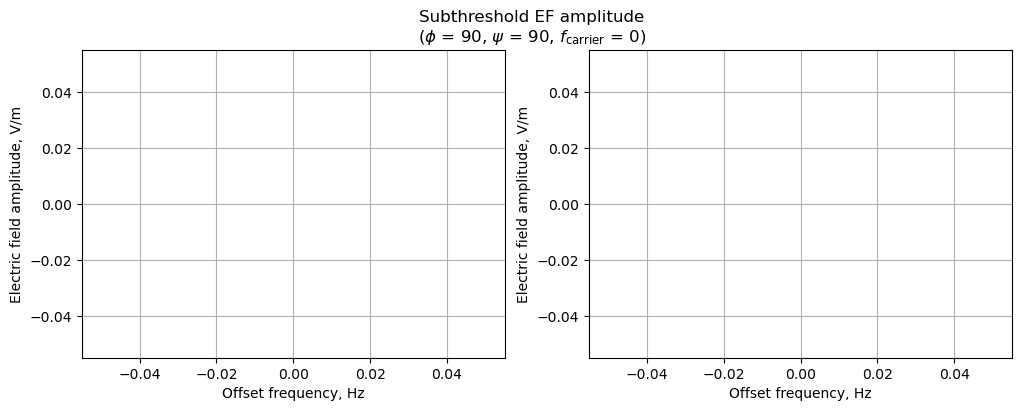

In [5]:
plot_subthreshold_amplitude(subthreshold, phi = 90, psi = 90, carrier = 0)